# **Theoretical Questions**







**1.Can we use Bagging for regression problems?**

  Ans: Yes.
Bagging works for both classification and regression.

Bagging Regressor:

Trains multiple regression models on bootstrap samples

Final prediction = average of all model predictions

Example: BaggingRegressor, RandomForestRegressor


**2.What is the difference between multiple model training and single model training?**

Ans:
| Aspect      | Single Model       | Multiple Models (Ensemble) |
| ----------- | ------------------ | -------------------------- |
| Models      | One model          | Many models                |
| Accuracy    | Moderate           | Higher                     |
| Overfitting | High risk          | Reduced                    |
| Stability   | Sensitive to noise | More stable                |
| Complexity  | Simple             | Complex                    |



**3.Explain the concept of feature randomness in Random Forest?**

Ans: Random Forest introduces feature randomness by:

Selecting a random subset of features at each split

Prevents trees from becoming similar

Reduces correlation among trees

Improves generalization

**4.What is OOB (Out-of-Bag) Score?**

Ans: Each tree is trained on ~63% of data (bootstrap sampling)

Remaining ~37% = Out-of-Bag samples

Used as a validation set

OOB Score ≈ Cross-validation score (no extra validation needed)

**5.How can you measure the importance of features in a Random Forest model?**

Ans: Two common methods:

Gini Importance / Mean Decrease in Impurity

How much a feature reduces node impurity

Permutation Importance

Shuffle feature values and measure performance drop

**6.Explain the working principle of a Bagging Classifier?**

Ans: Create multiple bootstrap samples

Train a base classifier (e.g., Decision Tree) on each sample

Combine predictions using majority voting

Final class = most voted class

**7.How do you evaluate a Bagging Classifier’s performance?**

Ans: Accuracy

Precision, Recall, F1-score

ROC–AUC

Confusion Matrix

OOB Score (if available)

Cross-validation

**8.How does a Bagging Regressor work?**

Ans: Draw bootstrap samples

Train regression models independently

Predict for each model

Final output = mean of predictions

**9.What is the main advantage of ensemble techniques?**

Ans: Improved accuracy and robustness

Reduces variance

Improves generalization

More reliable than individual models

**10.What is the main challenge of ensemble methods?**

Ans: Higher complexity

Increased training time

Higher memory usage

Less interpretability

**11.Explain the key idea behind ensemble techniques?**

Ans: Combine multiple weak learners to create a strong learner

Errors of individual models cancel out

Collective decision is more accurate

**12.What is a Random Forest Classifier?**

Ans: Ensemble of Decision Trees

Uses Bagging + Feature Randomness

Final prediction via majority voting

Highly robust and accurate

**13.What are the main types of ensemble techniques?**

Ans: Bagging (Bootstrap Aggregating)

Boosting

Stacking

Voting

 **14.What is ensemble learning in machine learning?**

 Ans: Ensemble learning combines multiple models to improve:

Accuracy

Stability

Generalization

 **15.When should we avoid using ensemble methods?**

 Ans: Dataset is very small

Real-time/low-latency systems

Model interpretability is critical

Limited computational resources

**16.How does Bagging help in reducing overfitting?**

Ans: Trains models on different subsets

Reduces variance

Averages out noise

Works best with high-variance models (e.g., Decision Trees)

 **17.Why is Random Forest better than a single Decision Tree?**

 Ans:
 | Decision Tree     | Random Forest    |
| ----------------- | ---------------- |
| Overfits          | Less overfitting |
| High variance     | Low variance     |
| Sensitive to data | Robust           |
| Lower accuracy    | Higher accuracy  |


**18.What is the role of bootstrap sampling in Bagging?**

Ans: Random sampling with replacement

Creates diverse datasets

Ensures model diversity

Key to variance reduction

 **19.What are some real-world applications of ensemble techniques?**

 Ans: Fraud detection

Credit scoring

Medical diagnosis

Recommendation systems

Image classification

Stock market prediction

**20.What is the difference between Bagging and Boosting?**

Ans:
| Feature       | Bagging         | Boosting          |
| ------------- | --------------- | ----------------- |
| Training      | Parallel        | Sequential        |
| Focus         | Reduce variance | Reduce bias       |
| Data sampling | Random          | Weighted          |
| Overfitting   | Reduces         | Can increase      |
| Examples      | Random Forest   | AdaBoost, XGBoost |


# **Practical Questions**

In [3]:
#Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


bagging_clf.fit(X_train, y_train)


y_pred = bagging_clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print(f"Bagging Classifier Accuracy: {accuracy:.4f}")




Bagging Classifier Accuracy: 0.9474


In [4]:
#Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


X, y = fetch_california_housing(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_reg.fit(X_train, y_train)


y_pred = bagging_reg.predict(X_test)


mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")


Mean Squared Error (MSE): 0.2599


In [5]:
#Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)


feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)


print(feature_importances)


                    Feature  Importance
23               worst area    0.140016
27     worst concave points    0.129530
20             worst radius    0.097696
7       mean concave points    0.090885
22          worst perimeter    0.072226
2            mean perimeter    0.069574
0               mean radius    0.068676
6            mean concavity    0.057638
3                 mean area    0.049172
26          worst concavity    0.034340
13               area error    0.033104
25        worst compactness    0.018600
21            worst texture    0.018597
10             radius error    0.016770
24         worst smoothness    0.012436
5          mean compactness    0.011715
12          perimeter error    0.009633
1              mean texture    0.009584
28           worst symmetry    0.008335
15        compactness error    0.005979
4           mean smoothness    0.005598
11            texture error    0.005214
29  worst fractal dimension    0.005166
8             mean symmetry    0.004666


In [6]:
#Train a Random Forest Regressor and compare its performance with a single Decision Tree
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


X, y = fetch_california_housing(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)

dt_pred = dt_reg.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)


rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)


print("Decision Tree Regressor:")
print(f"  MSE: {dt_mse:.4f}")
print(f"  R² : {dt_r2:.4f}")

print("\nRandom Forest Regressor:")
print(f"  MSE: {rf_mse:.4f}")
print(f"  R² : {rf_r2:.4f}")


Decision Tree Regressor:
  MSE: 0.4952
  R² : 0.6221

Random Forest Regressor:
  MSE: 0.2554
  R² : 0.8051


In [36]:
#Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_clf = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

# Print OOB score
print(f"Out-of-Bag (OOB) Score: {rf_clf.oob_score_:.4f}")


Out-of-Bag (OOB) Score: 0.9604


In [8]:
# Train a Bagging Classifier using SVM as a base estimator and print accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
]
bagging_svm = BaggingClassifier(
    estimator=svm_pipeline,
    n_estimators=20,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_svm.fit(X_train, y_train)


y_pred = bagging_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Bagging SVM Classifier Accuracy: {accuracy:.4f}")


Bagging SVM Classifier Accuracy: 0.9825


In [9]:
#Train a Random Forest Classifier with different numbers of trees and compare accuracy
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n_estimators_list = [10, 50, 100, 200, 500]

results = []

for n in n_estimators_list:
    rf_clf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf_clf.fit(X_train, y_train)
    y_pred = rf_clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "n_estimators": n,
        "Accuracy": accuracy
    })


results_df = pd.DataFrame(results)
print(results_df)


   n_estimators  Accuracy
0            10  0.938596
1            50  0.956140
2           100  0.956140
3           200  0.956140
4           500  0.956140


In [10]:
#Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, solver="lbfgs"))
])

bagging_logreg = BaggingClassifier(
    estimator=logreg_pipeline,
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-
bagging_logreg.fit(X_train, y_train)


y_prob = bagging_logreg.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, y_prob)

print(f"Bagging Logistic Regression AUC: {auc:.4f}")


Bagging Logistic Regression AUC: 0.9954


Top 5 Most Important Features:
     Feature  Importance
0     MedInc    0.524871
5   AveOccup    0.138443
6   Latitude    0.088936
7  Longitude    0.088629
1   HouseAge    0.054593


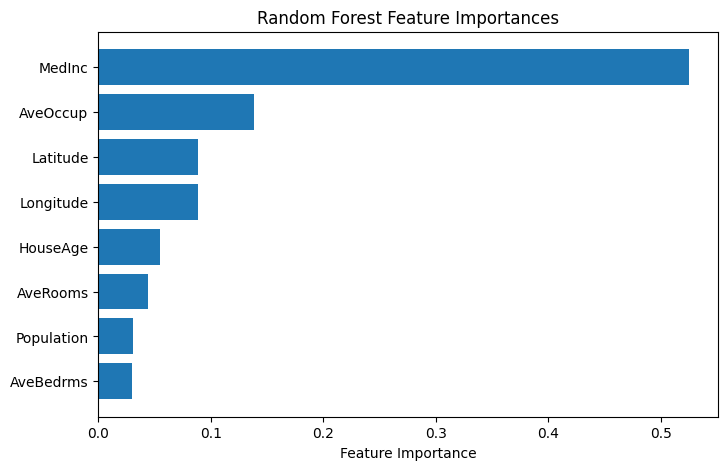

In [30]:
#Train a Random Forest Regressor and analyze feature importance scores
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


X, y = fetch_california_housing(return_X_y=True)
feature_names = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
    'AveOccup', 'Latitude', 'Longitude'
]
X = pd.DataFrame(X, columns=feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)


importances = rf_reg.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))


plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.show()


In [11]:
# Train an ensemble model using both Bagging and Random Forest and compare accuracy
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred_bag = bagging_clf.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Bagging Classifier Accuracy: {acc_bag:.4f}")
print(f"Random Forest Classifier Accuracy: {acc_rf:.4f}")


Bagging Classifier Accuracy: 0.9474
Random Forest Classifier Accuracy: 0.9561


In [35]:
# Train a Bagging Regressor with different numbers of base estimators and compare performance
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_estimators_list = [10, 50, 100, 200]

results = []

for n in n_estimators_list:

    bagging_reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=n,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )


    bagging_reg.fit(X_train, y_train)

    y_pred = bagging_reg.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "n_estimators": n,
        "MSE": mse,
        "R2": r2
    })
results_df = pd.DataFrame(results)
print(results_df)


   n_estimators       MSE        R2
0            10  0.293604  0.775945
1            50  0.264260  0.798338
2           100  0.259889  0.801673
3           200  0.257206  0.803721


In [16]:
# Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print("Decision Tree Confusion Matrix:")
print(pd.DataFrame(cm_dt, index=["malignant","benign"], columns=["malignant","benign"]))


bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred_bag = bagging_clf.predict(X_test)

acc_bag = accuracy_score(y_test, y_pred_bag)
cm_bag = confusion_matrix(y_test, y_pred_bag)

print(f"\nBagging Classifier Accuracy: {acc_bag:.4f}")
print("Bagging Classifier Confusion Matrix:")
print(pd.DataFrame(cm_bag, index=["malignant","benign"], columns=["malignant","benign"]))


Decision Tree Accuracy: 0.9123
Decision Tree Confusion Matrix:
           malignant  benign
malignant         39       3
benign             7      65

Bagging Classifier Accuracy: 0.9474
Bagging Classifier Confusion Matrix:
           malignant  benign
malignant         39       3
benign             3      69


Test Accuracy: 0.9561


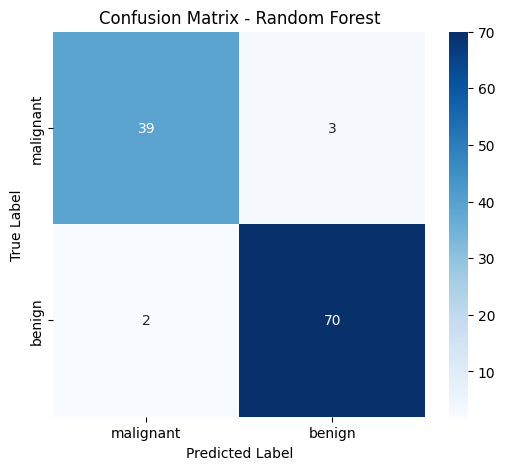

In [33]:
#Train a Random Forest Classifier and visualize the confusion matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_clf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=data.target_names, columns=data.target_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



In [21]:
# Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=Tree)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

base_estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', Pipeline([
        ('scaler', StandardScaler()),   # SVM requires scaling
        ('svc', SVC(kernel='rbf', probability=True))
    ])),
    ('lr', LogisticRegression(max_iter=1000))
]


stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)


stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_clf.predict(X_test))


svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])
svm_pipeline.fit(X_train, y_train)
acc_svm = accuracy_score(y_test, svm_pipeline.predict(X_test))


lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, lr_clf.predict(X_test))


print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"SVM Accuracy: {acc_svm:.4f}")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Stacking Classifier Accuracy: {acc_stack:.4f}")


Decision Tree Accuracy: 0.9123
SVM Accuracy: 0.9825
Logistic Regression Accuracy: 0.9649
Stacking Classifier Accuracy: 0.9825


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
#Train a Random Forest Classifier and print the top 5 most important features
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)


importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


print("Top 5 Most Important Features:")
print(feature_importance_df.head(5))


Top 5 Most Important Features:
                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226


In [26]:
#Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy:.4f}\n"
report = classification_report(y_test, y_pred, target_names=load_breast_cancer().target_names)
print("Classification Report:")
print(report)


Test Set Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



max_depth=None, Train Accuracy=1.0000, Test Accuracy=0.9561
max_depth=2, Train Accuracy=0.9648, Test Accuracy=0.9474
max_depth=4, Train Accuracy=0.9934, Test Accuracy=0.9561
max_depth=6, Train Accuracy=0.9956, Test Accuracy=0.9474
max_depth=8, Train Accuracy=1.0000, Test Accuracy=0.9561
max_depth=10, Train Accuracy=1.0000, Test Accuracy=0.9561
max_depth=12, Train Accuracy=1.0000, Test Accuracy=0.9561
max_depth=15, Train Accuracy=1.0000, Test Accuracy=0.9561


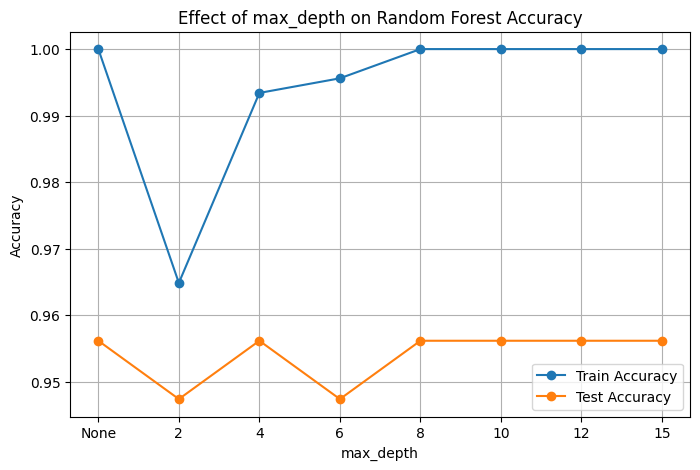

In [28]:
#Train a Random Forest Classifier and analyze the effect of max_depth on accuracy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


max_depth_values = [None, 2, 4, 6, 8, 10, 12, 15]


train_accuracies = []
test_accuracies = []

for depth in max_depth_values:

    rf_clf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    rf_clf.fit(X_train, y_train)


    train_acc = accuracy_score(y_train, rf_clf.predict(X_train))
    test_acc = accuracy_score(y_test, rf_clf.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


for i, depth in enumerate(max_depth_values):
    print(f"max_depth={depth}, Train Accuracy={train_accuracies[i]:.4f}, Test Accuracy={test_accuracies[i]:.4f}")


plt.figure(figsize=(8,5))
plt.plot([str(d) for d in max_depth_values], train_accuracies, marker='o', label='Train Accuracy')
plt.plot([str(d) for d in max_depth_values], test_accuracies, marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [29]:
#Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


X, y = fetch_california_housing(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_estimators = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "KNeighbors": KNeighborsRegressor(n_neighbors=5)
}

results = []

for name, estimator in base_estimators.items():

    bagging_reg = BaggingRegressor(
        estimator=estimator,
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    bagging_reg.fit(X_train, y_train)

    y_pred = bagging_reg.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Base Estimator": name,
        "MSE": mse,
        "R2": r2
    })


results_df = pd.DataFrame(results)
print(results_df)


  Base Estimator       MSE        R2
0   DecisionTree  0.259889  0.801673
1     KNeighbors  1.076154  0.178765


ROC-AUC Score: 0.9937


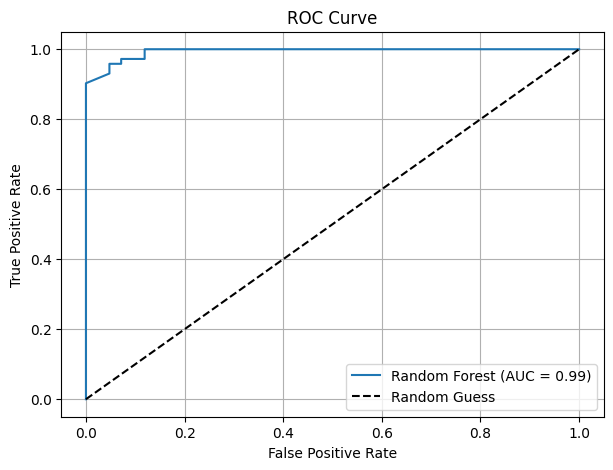

In [27]:
#Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)


y_prob = rf_clf.predict_proba(X_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
#Train a Bagging Classifier and evaluate its performance using cross-validatio
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


X, y = load_breast_cancer(return_X_y=True)


bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


cv_scores = cross_val_score(bagging_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

# Print results
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation: {np.std(cv_scores):.4f}")


Cross-validation accuracy scores: [0.89473684 0.94736842 0.99122807 0.96491228 0.99115044]
Mean cross-validation accuracy: 0.9579
Standard deviation: 0.0357


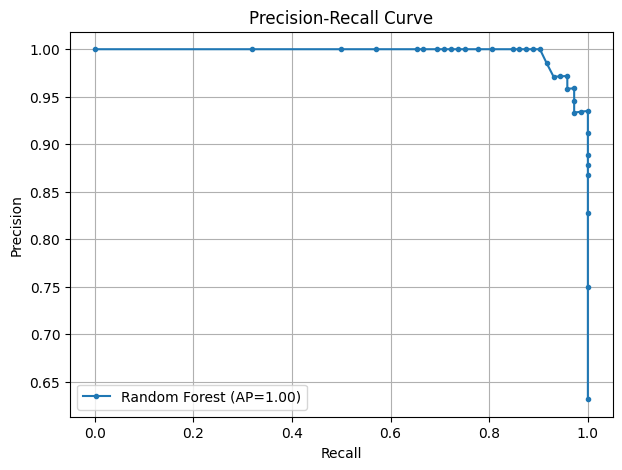

In [22]:
# Train a Random Forest Classifier and plot the Precision-Recall curve
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score


X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)


y_prob = rf_clf.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)


plt.figure(figsize=(7,5))
plt.plot(recall, precision, marker='.', label=f'Random Forest (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, solver='lbfgs'))
]


stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)


stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_clf.predict(X_test))

lr_clf = LogisticRegression(max_iter=1000, solver='lbfgs')
lr_clf.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, lr_clf.predict(X_test))

# Print results
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Stacking Classifier Accuracy: {acc_stack:.4f}")


Random Forest Accuracy: 0.9561
Logistic Regression Accuracy: 0.9649
Stacking Classifier Accuracy: 0.9561


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
